# Experiment Setup

Log for defining experiment parameters.

## Table of Contents

1. [Properties of the case [2026-01-28]](#properties-of-the-case)
2. [Sea-states [2026-01-29]](#sea-states)

<a id="properties-of-the-case"></a>

## Properties of the case [2026-01-28]

In [54]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM
PKG_ROOT = HydroElasticFEM.PKG_ROOT

using JLD2
using Printf
using DataFrames
using Plots
using Printf
using WaveSpec.Constants
using WaveSpec.Jonswap

  Activating project at `~/Acads/HydroElasticFEM.jl`


### Option 1: LDPE Lm=50

Still-water depth = H0 = 25m

```Julia
E = 100e6 #Pa
ρ = 910 #kg/m3

Lm = 50.0 #m
h_memb = 0.05*16 #m
ϵx = 0.002 #Pre Strain 

σx = E*ϵx #Pre stress
T = σx*h_memb #Pre tension

m = ρ*h_memb #Mass per unit area
```


```Console
Typical Yield Strength (TYS) = 10MPa
Pre-Stress σx = 0.20 MPa = 2.0% TYS

[MSG] Membrane Properties:
[VAL] Density of water, ρw = 1025.00 kg/m3
[VAL] Lm = 50.0000 m
[VAL] m, mᵨ = 728.0000 kg/m2, 0.7102 m
[VAL] T, Tᵨ = 160000.0000 N/m, 156.0976 m3/s2
[VAL] τ = 0.0000 
[VAL] memBndType = HydroElasticFEM.Membrane.Free() 
[VAL] MTotal = 36400.0000 kg/m 
[VAL] 1st Dry Analytical Natural Freq, ωn1 = 0.9315 rad/s 


[MSG] Resonator Properties:
[VAL] M = 3640.0000 kg
[VAL] K = 0.0000 N/m
[VAL] C = 0.0000 Ns/m
[VAL] XZ = (75.0000, 0.0000) m
[VAL] ωn1 = 0.0000 rad/s


```

Mesh = (0,50,100,150)
nx,nz = (375, 15, 1.15)

**Dry Natural Freqs**

```Console
7×3 DataFrame
 Row │ ωn                V                                  meff             
     │ Complex…          Array…                             Complex…         
─────┼───────────────────────────────────────────────────────────────────────
   1 │ 2.62313e-6+0.0im  ComplexF64[0.0629941+0.0im, 0.06…    0.460196+0.0im
   2 │   0.509199+0.0im  ComplexF64[-0.04433+0.0im, -0.04…      69.492+0.0im
   3 │   0.931481+0.0im  ComplexF64[-0.0890871+0.0im, -0.…  0.00880759+0.0im
   4 │    1.87016+0.0im  ComplexF64[-0.0889154+0.0im, -0.…    0.014137+0.0im
   5 │    2.79444+0.0im  ComplexF64[0.0890871+0.0im, 0.08…  0.00880759+0.0im
   6 │    3.72934+0.0im  ComplexF64[0.0890465+0.0im, 0.08…  0.00910986+0.0im
   7 │    4.65741+0.0im  ComplexF64[-0.0890871-0.0im, -0.…  0.00880758+0.0im
```

**Wet Natural Freqs**

```Console
7×4 DataFrame
 Row │ ωn                     V                                  meff                  iter  
     │ Complex…               Any                                Any                   Int64 
─────┼───────────────────────────────────────────────────────────────────────────────────────
   1 │      0.0+0.0im         ComplexF64[0.0+0.0im, 0.0+0.0im,…  0.0+0.0im                 0
   2 │ 0.499651-1.55955e-5im  ComplexF64[-4.51676e-5+4.09873e-…  113.749+4.87304e-6im      2
   3 │ 0.971825-0.193344im    ComplexF64[-0.0746939-0.0264458i…  1.71952+0.148832im       12
   4 │  1.24908-0.168326im    ComplexF64[0.0876051+0.00847866i…  0.868607-0.389205im      14
   5 │  1.48423-0.157743im    ComplexF64[-0.0940719-0.00137344…  0.53592-0.311784im       13
   6 │   1.6994-0.149686im    ComplexF64[0.0983227+0.000479656…  0.419326-0.197135im      12
   7 │   1.9054-0.142164im    ComplexF64[-0.10142-1.82063e-13i…  0.348002-0.122468im      11
```

#### Mode Shape

In [55]:
# Without Resonator
fileName = "data/paper2026_01/01_ExperimentSetup/"
fileName *= "runlrhs_Lm50_hm0p800_resnMNOT_STAR/"
fileName *= "mem_data.jld2"
df1 = load(PKG_ROOT*fileName)

┌ Warning: type Main.run_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dict{String, Any} with 16 entries:
  "prbDa_x"           => 119×20 DataFrame…
  "ω"                 => [0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0…
  "η₀"                => [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1  …  …
  "prbResnRAO"        => 119×4 DataFrame…
  "prbPow_Header"     => "ω, Pin, Prf, Ptr, Pd, PErr, 0.0, Pd_r..."
  "prbDaΓη"           => 119×101 DataFrame…
  "prxΓκ"             => VectorValue{2, Float64}[(-300.0, 0.0), (-299.5, 0.0), …
  "prbPow"            => 119×8 DataFrame…
  "prbDa"             => 119×20 DataFrame…
  "prxΓη"             => VectorValue{2, Float64}[(0.0, 0.0), (0.5, 0.0), (1.0, …
  "k"                 => [0.0199204, 0.021366, 0.0228361, 0.0243325, 0.0258574,…
  "params"            => Reconstruct@run_params(Any["data/paper2026_01/runlrhs2…
  "resn"              => Single[Single(3640.0, 0.0, 0.0, (25.0, 0.0), 0.0)]
  "prbResnRAO_Header" => "ω, q_resn, η_resn, Pd_resn..."
  "prbxy"             => VectorValue{2, Float64}[(-300.0, 0.0), 

In [56]:
# With Resonator
fileName = "data/paper2026_01/01_ExperimentSetup/"
fileName *= "runlrhs_Lm50_hm0p800_resnM3640p0_STAR/"
fileName *= "mem_data.jld2"
df2 = load(PKG_ROOT*fileName)

┌ Warning: type Main.run_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dict{String, Any} with 16 entries:
  "prbDa_x"           => 119×20 DataFrame…
  "ω"                 => [0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0…
  "η₀"                => [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1  …  …
  "prbResnRAO"        => 119×4 DataFrame…
  "prbPow_Header"     => "ω, Pin, Prf, Ptr, Pd, PErr, 0.0, Pd_r..."
  "prbDaΓη"           => 119×101 DataFrame…
  "prxΓκ"             => VectorValue{2, Float64}[(-300.0, 0.0), (-299.5, 0.0), …
  "prbPow"            => 119×8 DataFrame…
  "prbDa"             => 119×20 DataFrame…
  "prxΓη"             => VectorValue{2, Float64}[(0.0, 0.0), (0.5, 0.0), (1.0, …
  "k"                 => [0.0199204, 0.021366, 0.0228361, 0.0243325, 0.0258574,…
  "params"            => Reconstruct@run_params(Any["data/paper2026_01/runlrhs"…
  "resn"              => Single[Single(3640.0, 910.0, 0.0, (25.0, 0.0), 0.5)]
  "prbResnRAO_Header" => "ω, q_resn, η_resn, Pd_resn..."
  "prbxy"             => VectorValue{2, Float64}[(-300.0, 0.0)

In [57]:
ω_nat = [
  [0.51797, 0.931481, 1.87729,], #Dry
  [         0.960528, 1.31615, 1.71873, 2.17498], #Wet without resonator
  [0.497066, 0.960528, 1.31806, 1.71873, 2.17691] #Wet with resonator
]

3-element Vector{Vector{Float64}}:
 [0.51797, 0.931481, 1.87729]
 [0.960528, 1.31615, 1.71873, 2.17498]
 [0.497066, 0.960528, 1.31806, 1.71873, 2.17691]

In [58]:
function plotCoeff(plt1, plt2, ω, prbPow)
  plt1 = plot(ω, prbPow[:,3]./prbPow[:,2], linewidth=3, 
    xlabel = "ω (rad/s)",
    ylabel = "K_R",
    title = "Reflection coefficient",
    ylims = (0,1.0))

  plt2 = plot(ω, prbPow[:,4]./prbPow[:,2], linewidth=3, 
    xlabel = "ω (rad/s)",
    ylabel = "K_T",
    title = "Transmission coefficient",
    ylims = (0,1.0))
end

plotCoeff (generic function with 1 method)

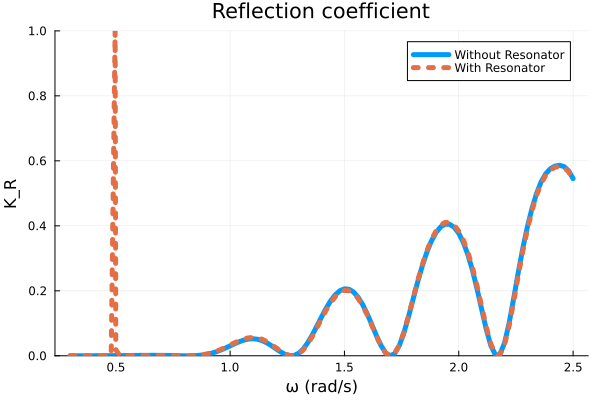

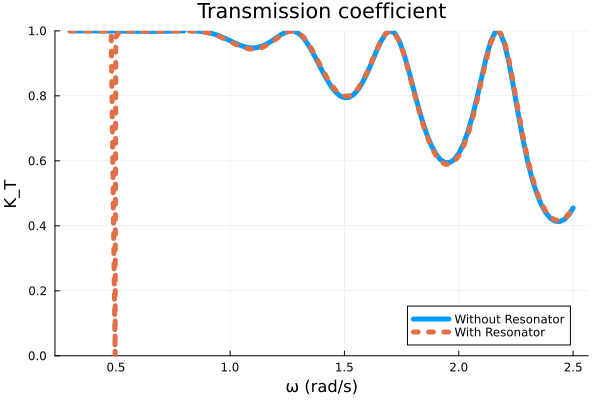

In [59]:
plt1 = plot()
plt2 = plot()

prbPow = df1["prbPow"]
ω = df1["ω"]
plt1 = plot(ω, prbPow[:,3]./prbPow[:,2], linewidth=5, label="Without Resonator")
plt2 = plot(ω, prbPow[:,4]./prbPow[:,2], linewidth=5, label="Without Resonator")


prbPow = df2["prbPow"]
ω = df2["ω"]
plot!(plt1, ω, prbPow[:,3]./prbPow[:,2], linewidth=5, linestyle=:dot, 
  label="With Resonator")
plot!(plt2, ω, prbPow[:,4]./prbPow[:,2], linewidth=5, linestyle=:dot,
  label="With Resonator")


plot!(plt1,
  xlabel = "ω (rad/s)",
  ylabel = "K_R",
  title = "Reflection coefficient",
  ylims = (0,1.0))


plot!(plt2,
  xlabel = "ω (rad/s)",
  ylabel = "K_T",
  title = "Transmission coefficient",
  ylims = (0,1.0))

display(plt1)
savefig(plt1, "ReflectionCoefficient.png")
savefig(plt2, "TransmissionCoefficient.png")
display(plt2)


## Sea State

In [60]:
# With Resonator
fileName = "data/paper2026_01/01_ExperimentSetup/"
fileName *= "runlrhs_Lm50_hm0p800_resnM3640p0_resnC0p05_membtau0p05_Hs3p0_Tp10p0/"
# fileName *= "runlrhs_Lm50_hm0p800_resnM3640p0_resnC0p05_membtau0p05_Hs7p0_Tp12p4/"
fileName *= "mem_data.jld2"
df3 = load(PKG_ROOT*fileName)

┌ Warning: type Main.run_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


Dict{String, Any} with 16 entries:
  "prbDa_x"           => 111×20 DataFrame…
  "ω"                 => [0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0…
  "η₀"                => [1.61239e-5, 0.000211689, 0.00134473, 0.00517104, 0.01…
  "prbResnRAO"        => 111×4 DataFrame…
  "prbPow_Header"     => "ω, Pin, Prf, Ptr, Pd, PErr, 0.0, Pd_r..."
  "prbDaΓη"           => 111×101 DataFrame…
  "prxΓκ"             => VectorValue{2, Float64}[(-300.0, 0.0), (-299.5, 0.0), …
  "prbPow"            => 111×8 DataFrame…
  "prbDa"             => 111×20 DataFrame…
  "prxΓη"             => VectorValue{2, Float64}[(0.0, 0.0), (0.5, 0.0), (1.0, …
  "k"                 => [0.0199204, 0.021366, 0.0228361, 0.0243325, 0.0258574,…
  "params"            => Reconstruct@run_params(Any["data/paper2026_01/runlrhs"…
  "resn"              => Single[Single(3640.0, 910.0, 45.5, (25.0, 0.0), 0.5)]
  "prbResnRAO_Header" => "ω, q_resn, η_resn, Pd_resn..."
  "prbxy"             => VectorValue{2, Float64}[(-300.0, 0.0

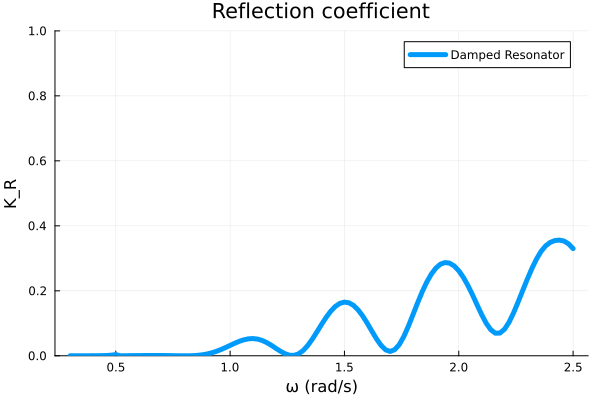

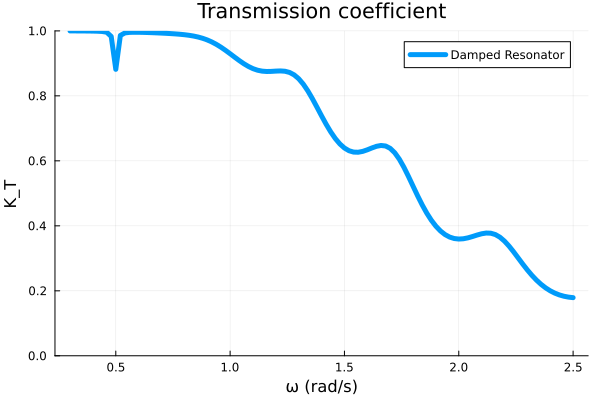

In [61]:
plt1 = plot()
plt2 = plot()

prbPow = df3["prbPow"]
ω = df3["ω"]
plt1 = plot(ω, prbPow[:,3]./prbPow[:,2], linewidth=5, label="Damped Resonator")
plt2 = plot(ω, prbPow[:,4]./prbPow[:,2], linewidth=5, label="Damped Resonator")



plot!(plt1,
  xlabel = "ω (rad/s)",
  ylabel = "K_R",
  title = "Reflection coefficient",
  ylims = (0,1.0))


plot!(plt2,
  xlabel = "ω (rad/s)",
  ylabel = "K_T",
  title = "Transmission coefficient",
  ylims = (0,1.0))

display(plt1)
# savefig(plt1, "ReflectionCoefficient.png")
# savefig(plt2, "TransmissionCoefficient.png")
display(plt2)

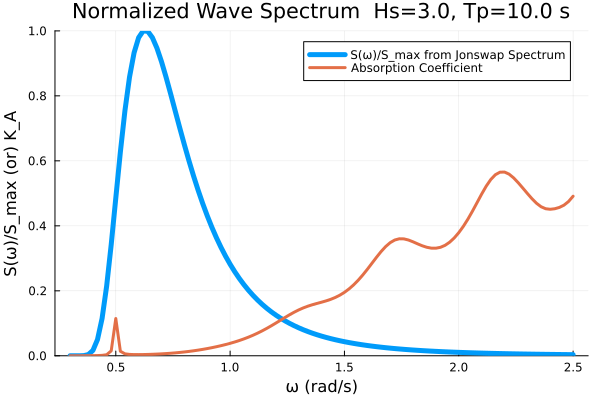

ERR: Check criterion Tₚ / √(Hₛ) = 5.773502691896258
Hₛ 	 3.0
Tₚ 	 10.0
ωₚ 	 0.628
γ 	 1.0
Ag 	 1.005
Computed Hₛ 	 3.0
Computed ωₛ 	 0.802
Max(S) 	1.287
Max(A) 	0.227
df3["prbPow_Header"] = "ω, Pin, Prf, Ptr, Pd, PErr, 0.0, Pd_r..."


"/home/shagun/Acads/HydroElasticFEM.jl/Paper2026/notes/NWO_Report/AbsorptionCoefficient.png"

In [62]:
Hs = 3.0
Tp = 10.0
ω_run, S_run, η0_run = jonswap(Hs, Tp; 
      plotflag=false, nω=126, ωc = 2.5)
mask = findall(ω_run .>= 0.3)
ω_run = ω_run[mask]
S_run = S_run[mask]
η0_run = η0_run[mask]

S_max = maximum(S_run)

plt1 = plot(ω_run, S_run./S_max, linewidth=5,  
  label="S(ω)/S_max from Jonswap Spectrum",
  title = "Normalized Wave Spectrum Hs=$Hs, Tp=$Tp s",)


@show df3["prbPow_Header"]
prbPow = df3["prbPow"]
ω = df3["ω"]
PIn = df3["prbPow"][:,2]
PRef = df3["prbPow"][:,3] 
PTrans = df3["prbPow"][:,4] 
PAbs = (PIn .- PRef .- PTrans)./PIn

plot!(plt1, ω, PAbs, linewidth=3,  
  label = "Absorption Coefficient",
  ylims = (0,1.0))
plot!(plt1, xlabel = "ω (rad/s)",
  ylabel = "S(ω)/S_max (or) K_A",
  title = "Normalized Wave Spectrum  Hs=$Hs, Tp=$Tp s",
  ylims = (0,1.0))

display(plt1)
savefig(plt1, "AbsorptionCoefficient.png")



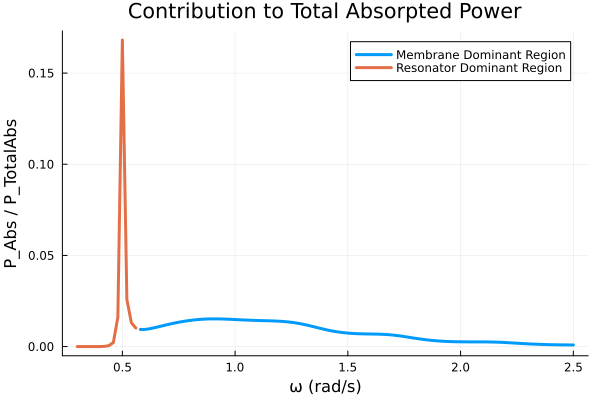

maximum(PAbs_norm) = 0.1681174562799679
sum(PAbs_norm[findall(mask2)]) = 0.763886206794797
sum(PAbs_norm[findall(!, mask2)]) = 0.2361137932052028


"/home/shagun/Acads/HydroElasticFEM.jl/Paper2026/notes/NWO_Report/AbsorptedPowerDistribution.png"

In [63]:
plt2  = plot()

PAbs = (PIn .- PRef .- PTrans)
PTot = sum(PAbs)
PAbs_norm = PAbs ./ PTot

@show maximum(PAbs_norm)
mask2 = ω .> 0.56
@show sum(PAbs_norm[findall(mask2)])
@show sum(PAbs_norm[findall(!,mask2)])


plot!(plt2, ω[mask2], PAbs_norm[mask2], linewidth=3, label="Membrane Dominant Region")
plot!(plt2, ω[.!mask2], PAbs_norm[.!mask2], linewidth=3, label="Resonator Dominant Region")
plot!(plt2,
  label = "Absorpted Power",
  xlabel = "ω (rad/s)",
  ylabel = "P_Abs / P_TotalAbs",
  title = "Contribution to Total Absorpted Power")

display(plt2)
savefig(plt2, "AbsorptedPowerDistribution.png")